# 🧪 **Task 7: ML Text Classification**
### **Objective:** Train a Logistic Regression model to classify scientific abstracts into three categories: *Cancer, Neuro, and Cardio*.

## 🛠️ **Step 1: Environment Setup & Library Installation**
**Action:** Import necessary libraries for data manipulation (`pandas`), machine learning (`scikit-learn`), and visualization (`seaborn`).

In [1]:
!pip install pandas scikit-learn matplotlib seaborn jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

## 📦 **Step 2: Data Generation**
**Action:** Generate a synthetic dataset of 100 scientific abstracts with labeled categories.
* **Input:** None (Synthetic Generation)
* **Output:** `scientific_abstracts.csv`

In [9]:
import random

def generate_synthetic_data():
    # Keywords to simulate domain-specific language
    cancer_terms = ['tumor', 'malignancy', 'oncology', 'metastasis', 'chemotherapy', 'carcinoma', 'apoptosis', 'biopsy']
    neuro_terms = ['neuron', 'synapse', 'brain', 'cortex', 'alzheimer', 'dopamine', 'plasticity', 'cognitive']
    cardio_terms = ['heart', 'cardiac', 'valve', 'artery', 'myocardium', 'stroke', 'vascular', 'hypertension']

    data = []

    # Generate ~34 entries per class to reach 100 total
    for _ in range(34):
        # Cancer sample
        data.append((f"Study of {random.choice(cancer_terms)} progression and {random.choice(cancer_terms)} response.", "Cancer"))
        # Neuro sample
        data.append((f"Analysis of {random.choice(neuro_terms)} signaling in the {random.choice(neuro_terms)}.", "Neuro"))
        # Cardio sample
        data.append((f"Effects on {random.choice(cardio_terms)} function during {random.choice(cardio_terms)} stress.", "Cardio"))

    # Trim to exactly 100 and shuffle (optional but good practice)
    random.shuffle(data)
    final_data = data[:100]

    df = pd.DataFrame(final_data, columns=['Abstract', 'Category'])
    df.to_csv('scientific_abstracts.csv', index=False)
    print(f"Dataset generated with {len(df)} samples.")
    return df

# Run the generation
df = generate_synthetic_data()
df.head()

Dataset generated with 100 samples.


,Abstract,Category
0,Analysis of plasticity signaling in the alzhei...,Neuro
1,Analysis of cortex signaling in the synapse.,Neuro
2,Study of carcinoma progression and biopsy resp...,Cancer
3,Study of biopsy progression and metastasis res...,Cancer
4,Analysis of plasticity signaling in the plasti...,Neuro


## ⚙️ **Step 3: Data Splitting & Feature Engineering**
**Action:**
1. Split data into **Training (80%)** and **Testing (20%)** sets.
2. Convert raw text into numerical vectors using **TF-IDF**.

In [10]:
# Load Data (redundant if you just ran Step 2, but good for restart safety)
df = pd.read_csv('scientific_abstracts.csv')

# Split Data
# X is the input text, y is the target label
X_train, X_test, y_train, y_test = train_test_split(
    df['Abstract'],
    df['Category'],
    test_size=0.2,
    random_state=42
)

print(f"Training Data: {X_train.shape[0]} samples")
print(f"Testing Data: {X_test.shape[0]} samples")

Training Data: 80 samples
Testing Data: 20 samples


In [11]:
# Initialize Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Fit on Train, Transform Train and Test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Vectorized Shape (Train): {X_train_tfidf.shape}")

Vectorized Shape (Train): (80, 32)


## 🧠 **Step 4: Model Training**
**Action:** Train a **Logistic Regression** classifier using the vectorized training data.

In [18]:
# Initialize Model
model = LogisticRegression()

# Train Model
model.fit(X_train_tfidf, y_train)

print("Model successfully trained.")

Model successfully trained.


## 📊 **Step 5: Performance Evaluation**
**Action:** Predict labels for the test set and calculate **Accuracy**, **Precision**, and **Recall**.

In [19]:
from sklearn.metrics import accuracy_score, classification_report  # Import added here

# Predict
y_pred = model.predict(X_test_tfidf)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00         5
      Cardio       1.00      1.00      1.00         6
       Neuro       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [20]:
from sklearn.metrics import accuracy_score, classification_report  # Import added here

# Predict
y_pred = model.predict(X_test_tfidf)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00         5
      Cardio       1.00      1.00      1.00         6
       Neuro       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 🎨 **Step 6: Visualization**
**Action:** Generate a **Confusion Matrix** heatmap to visualize correct vs. incorrect predictions.

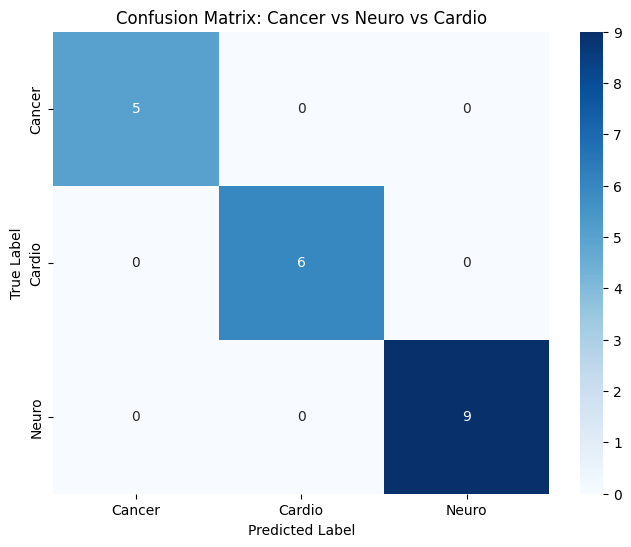

In [21]:
# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Cancer vs Neuro vs Cardio')
plt.show()

## ✅ **Step 7: Automated Pipeline Audit**
**Action:** Run a final validation script to ensure all steps (Data, TF-IDF, Model, Metrics) passed quality checks.

In [17]:
def validate_pipeline():
    print("--- STARTING PIPELINE AUDIT ---")

    # 1. Dataset Check
    try:
        assert len(df) == 100, f"FAIL: Dataset has {len(df)} rows, expected 100."
        assert 'Abstract' in df.columns, "FAIL: Column 'Abstract' missing."
        print("✅ Step 1: Dataset generation (100 samples) passed.")
    except NameError:
        print("❌ Step 1: 'df' not found. Did you run the generation step?")

    # 2. TF-IDF Check
    try:
        rows, cols = X_train_tfidf.shape
        assert rows > 0 and cols > 0, "FAIL: Matrix is empty."
        print(f"✅ Step 2: TF-IDF Vectorization passed. Vocab size: {cols}")
    except NameError:
        print("❌ Step 2: 'X_train_tfidf' not found.")

    # 3. Model Check
    try:
        from sklearn.utils.validation import check_is_fitted
        check_is_fitted(model)
        print("✅ Step 3: Model training passed (Model is fitted).")
    except Exception as e:
        print(f"❌ Step 3: Model not trained. Error: {e}")

    # 4. Evaluation Check
    try:
        assert 0.0 <= accuracy <= 1.0, "FAIL: Accuracy is out of bounds."
        print(f"✅ Step 4: Evaluation passed. Accuracy: {accuracy:.2f}")
    except NameError:
        print("❌ Step 4: 'accuracy' variable not found.")

    # 5. Visualization Check
    try:
        assert cm.shape[0] == cm.shape[1], "FAIL: Confusion matrix is not square."
        print(f"✅ Step 5: Confusion Matrix valid ({cm.shape[0]}x{cm.shape[1]}).")
    except NameError:
        print("❌ Step 5: 'cm' variable not found.")

    print("--- AUDIT COMPLETE ---")

# Run the validation
validate_pipeline()

--- STARTING PIPELINE AUDIT ---
✅ Step 1: Dataset generation (100 samples) passed.
✅ Step 2: TF-IDF Vectorization passed. Vocab size: 32
✅ Step 3: Model training passed (Model is fitted).
✅ Step 4: Evaluation passed. Accuracy: 1.00
✅ Step 5: Confusion Matrix valid (3x3).
--- AUDIT COMPLETE ---
